Projekt 

In [151]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
import scipy.ndimage as ndi
from skimage.filters import threshold_otsu
from skimage.segmentation import morphological_chan_vese
from skimage.morphology import remove_small_objects, remove_small_holes, binary_closing, disk, binary_opening
from skimage.measure import label, regionprops

In [153]:
radar_raw = (r"C:\Users\48881\Desktop\Cypo\projekt\lake-boundary-detection\obrazy\2026-05-06-00_00_2026-05-06-23_59_Sentinel-1_IW_VV+VH_VV_(Raw).tiff")
green_B03 = (r"C:\Users\48881\Desktop\Cypo\projekt\lake-boundary-detection\obrazy\2025-07-01-00_00_2025-07-01-23_59_Sentinel-2_L2A_B03_(Raw).tiff")
red_B04 = (r"C:\Users\48881\Desktop\Cypo\projekt\lake-boundary-detection\obrazy\2025-07-01-00_00_2025-07-01-23_59_Sentinel-2_L2A_B04_(Raw).tiff")
nir_B08 = (r"C:\Users\48881\Desktop\Cypo\projekt\lake-boundary-detection\obrazy\2025-07-01-00_00_2025-07-01-23_59_Sentinel-2_L2A_B08_(Raw).tiff")


In [154]:
with rasterio.open(radar_raw) as src:
    vv = src.read(1).astype("float32")
    print("Liczba pasm:", src.count)
    print("Min/max:", np.nanmin(vv), np.nanmax(vv))

vv[vv <= 0] = np.nan
vv_db = 10 * np.log10(vv)


median_value = np.nanmedian(vv_db)
vv_db_filled = np.nan_to_num(vv_db, nan=median_value)

vv_median = ndi.median_filter(vv_db_filled, size=9)

Liczba pasm: 1
Min/max: 0.0 1295.3575


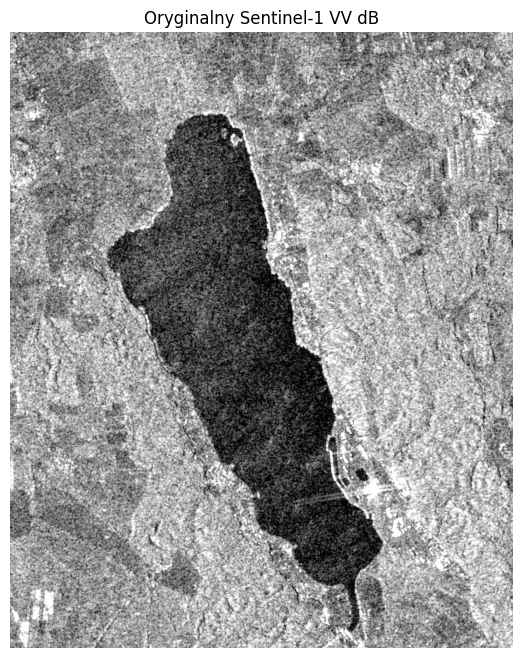

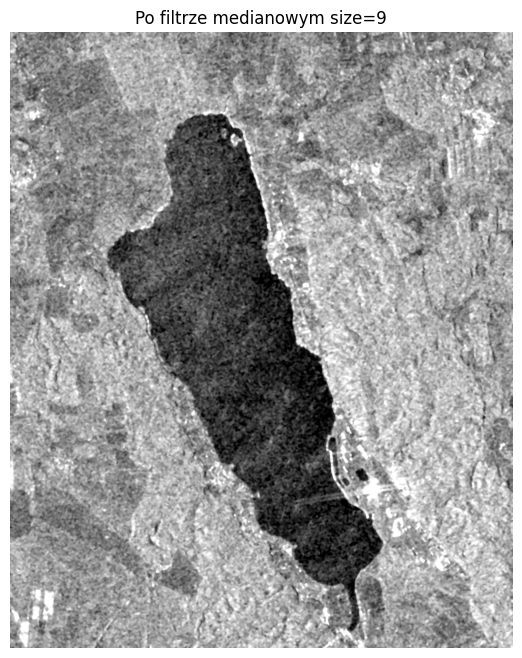

In [155]:
vmin, vmax = np.nanpercentile(vv_db, [2, 98])

plt.figure(figsize=(8, 8))
plt.imshow(vv_db, cmap="gray", vmin=vmin, vmax=vmax)
plt.title("Oryginalny Sentinel-1 VV dB")
plt.axis("off")
plt.show()

plt.figure(figsize=(8, 8))
plt.imshow(vv_median, cmap="gray", vmin=vmin, vmax=vmax)
plt.title("Po filtrze medianowym size=9")
plt.axis("off")
plt.show()

In [156]:
valid = np.isfinite(vv_median)
threshold = threshold_otsu(vv_median[valid])


initial_mask = vv_median < threshold


initial_mask = remove_small_objects(initial_mask.astype(bool), min_size=600)
initial_mask = remove_small_holes(initial_mask, area_threshold=600)


initial_mask = binary_closing(initial_mask, footprint=disk(3))
initial_mask = binary_opening(initial_mask, footprint=disk(2))

C:\Users\48881\AppData\Local\Temp\ipykernel_15584\3912474263.py:8: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  initial_mask = remove_small_objects(initial_mask.astype(bool), min_size=600)
C:\Users\48881\AppData\Local\Temp\ipykernel_15584\3912474263.py:9: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  initial

In [157]:
labels = label(initial_mask)
regions = regionprops(labels)

if len(regions) == 0:
    raise ValueError("Nie znaleziono żadnego obiektu w masce startowej.")

largest = max(regions, key=lambda r: r.area)
initial_mask_clean = labels == largest.label

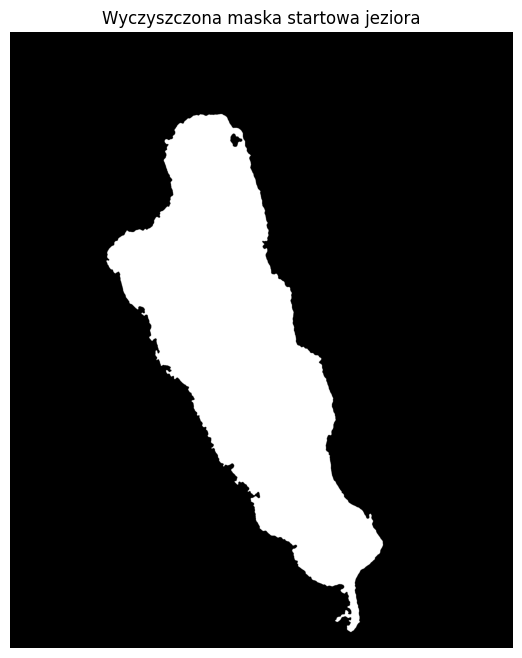

In [158]:
plt.figure(figsize=(8, 8))
plt.imshow(initial_mask_clean, cmap="gray")
plt.title("Wyczyszczona maska startowa jeziora")
plt.axis("off")
plt.show()

In [169]:

img = vv_median.copy()
img = np.nan_to_num(img, nan=np.nanmedian(img))
img_norm = (img - np.min(img)) / (np.max(img) - np.min(img))


img_inv = 1 - img_norm

lake_mask = morphological_chan_vese(
    img_inv,
    num_iter=8,
    init_level_set=initial_mask,
    smoothing=2,
    lambda1=1,
    lambda2=2
)

In [170]:
lake_mask_clean = remove_small_objects(lake_mask.astype(bool), min_size=1000)
lake_mask_clean = remove_small_holes(lake_mask_clean, area_threshold=1000)
lake_mask_clean = binary_closing(lake_mask_clean, footprint=disk(2))

C:\Users\48881\AppData\Local\Temp\ipykernel_15584\249698212.py:1: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  lake_mask_clean = remove_small_objects(lake_mask.astype(bool), min_size=1000)
C:\Users\48881\AppData\Local\Temp\ipykernel_15584\249698212.py:2: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  lake_mas

In [171]:
labels = label(lake_mask_clean)
regions = regionprops(labels)

if len(regions) > 0:
    largest_region = max(regions, key=lambda r: r.area)
    lake_mask_final = labels == largest_region.label
else:
    lake_mask_final = lake_mask_clean

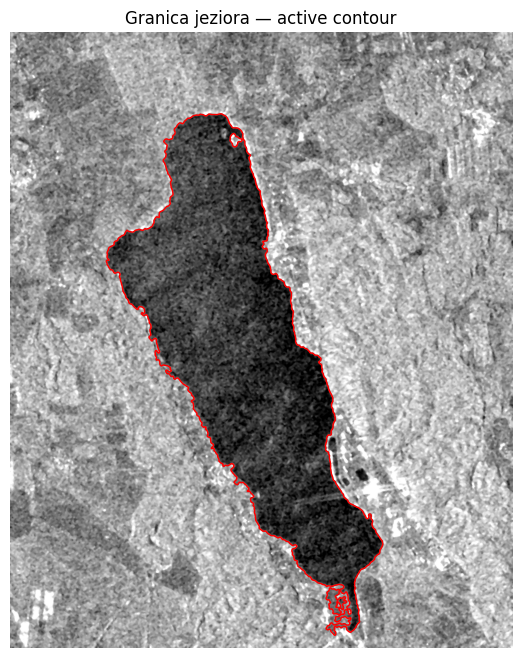

In [172]:
plt.figure(figsize=(8, 8))
plt.imshow(vv_median, cmap="gray", vmin=vmin, vmax=vmax)
plt.contour(lake_mask_final, colors="red", linewidths=1)
plt.title("Granica jeziora — active contour")
plt.axis("off")
plt.show()

In [173]:
with rasterio.open(green_B03) as src:
    green = src.read(1).astype("float32")
   
with rasterio.open(red_B04) as src:
    red = src.read(1).astype("float32")

with rasterio.open(nir_B08) as src:
    nir = src.read(1).astype("float32")

In [174]:
ndvi = (nir - red) / (nir + red)
ndwi = (green - nir) / (green + nir)

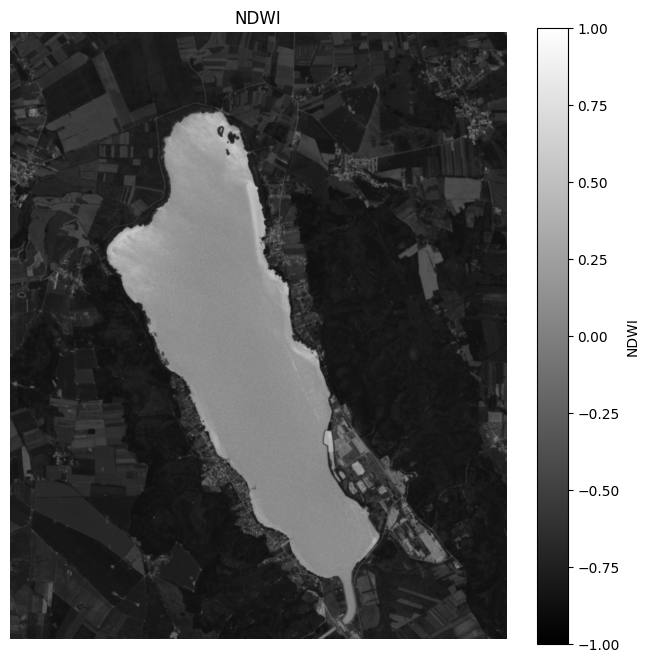

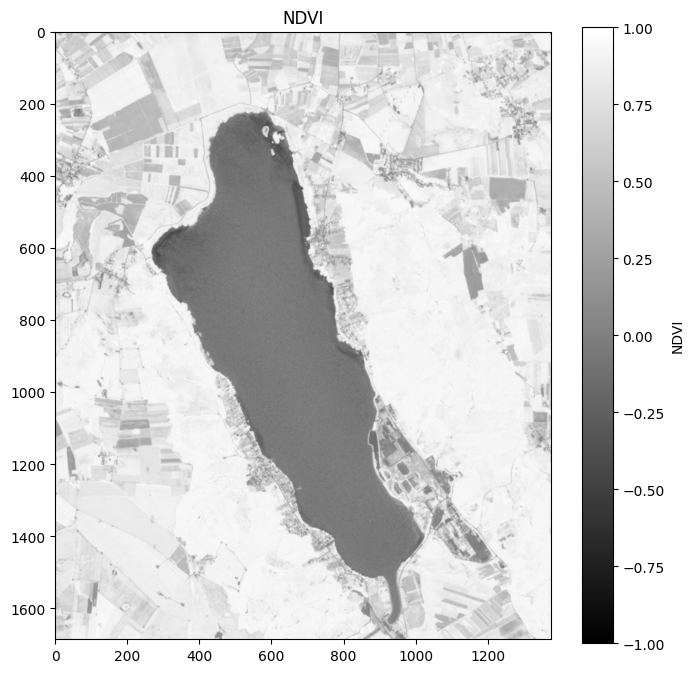

In [196]:
plt.figure(figsize=(8, 8))
plt.imshow(ndwi, cmap="gray", vmin=-1, vmax=1)
plt.colorbar(label="NDWI")
plt.title("NDWI")
plt.axis("off")
plt.show()

plt.figure(figsize=(8, 8))
plt.imshow(ndvi, cmap="gray", vmin=-1, vmax=1)
plt.colorbar(label="NDVI")
plt.title("NDVI")
plt.axis("on")
plt.show()

In [205]:
water_mask = (ndwi > 0.25) & (ndvi < 0.2)

In [206]:
print(ndwi.shape, ndvi.shape, water_mask.shape)

(1686, 1376) (1686, 1376) (1686, 1376)


In [201]:
water_mask = remove_small_objects(water_mask.astype(bool), min_size=500)
water_mask = remove_small_holes(water_mask, area_threshold=500)
water_mask = binary_closing(water_mask, footprint=disk(3))
water_mask = binary_opening(water_mask, footprint=disk(2))

C:\Users\48881\AppData\Local\Temp\ipykernel_15584\2494282056.py:1: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  water_mask = remove_small_objects(water_mask.astype(bool), min_size=500)
C:\Users\48881\AppData\Local\Temp\ipykernel_15584\2494282056.py:2: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  water_mask 

In [202]:
seed_y = 300
seed_x = 300

labels = label(water_mask)
lake_label = labels[seed_y, seed_x]

if lake_label == 0:
    raise ValueError("Punkt seed nie leży w masce jeziora. Zmień próg NDWI/NDVI albo seed_y, seed_x.")

lake_mask = labels == lake_label

ValueError: Punkt seed nie leży w masce jeziora. Zmień próg NDWI/NDVI albo seed_y, seed_x.

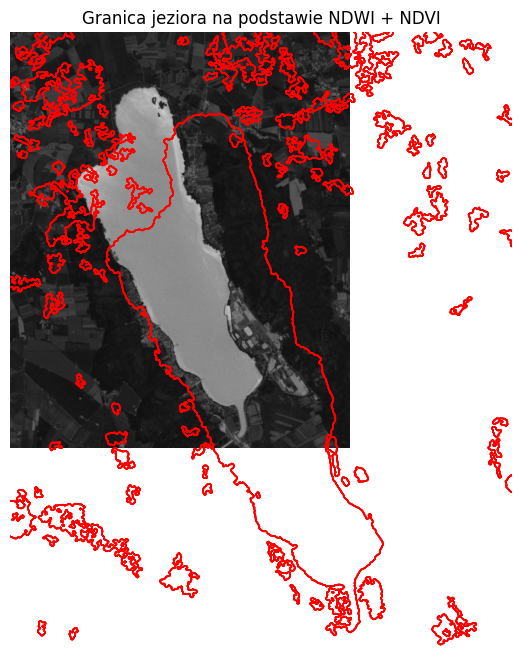

In [194]:
plt.figure(figsize=(8, 8))
plt.imshow(ndwi, cmap="gray", vmin=-1, vmax=1)
plt.contour(lake_mask, colors="red", linewidths=1)
plt.title("Granica jeziora na podstawie NDWI + NDVI")
plt.axis("off")
plt.show()

In [188]:
for name, path in {
    "green": green_B03,
    "red": red_B04,
    "nir": nir_B08
}.items():
    with rasterio.open(path) as src:
        print(name)
        print("  shape:", src.height, src.width)
        print("  crs:", src.crs)
        print("  transform:", src.transform)
        print("  nodata:", src.nodata)

green
  shape: 1686 1376
  crs: EPSG:4326
  transform: | 0.00, 0.00, 18.00|
| 0.00,-0.00, 54.81|
| 0.00, 0.00, 1.00|
  nodata: None
red
  shape: 1686 1376
  crs: EPSG:4326
  transform: | 0.00, 0.00, 18.00|
| 0.00,-0.00, 54.81|
| 0.00, 0.00, 1.00|
  nodata: None
nir
  shape: 1686 1376
  crs: EPSG:4326
  transform: | 0.00, 0.00, 18.00|
| 0.00,-0.00, 54.81|
| 0.00, 0.00, 1.00|
  nodata: None
